IMPORT THƯ VIỆN VÀ THUẬT TOÁN

In [2]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt


# Duong dan chinh xac den thu muc goc
project_folder = Path(
    r"C:\Users\LENOVO\Downloads\lab2.2 (1)"
)

if not (project_folder / "src").exists():
    raise FileNotFoundError(
        "Khong tim thay thu muc src"
    )

sys.path.insert(0, str(project_folder))


from src.edge_detection.canny_opencv import (
    detect_edges as detect_canny
)

from src.edge_detection.sobel import (
    detect_edges as detect_sobel
)

from src.edge_detection.laplacian import (
    detect_edges as detect_laplacian
)

print("Import thanh cong")

Import thanh cong


ĐỌC ẢNH

In [3]:
image_path = (
    project_folder
    / "data/input/normal/sample.png"
)

image = cv2.imread(
    str(image_path),
    cv2.IMREAD_COLOR
)

if image is None:
    print("Khong doc duoc anh:", image_path)
else:
    print("Da doc anh thanh cong")
    print("Kich thuoc anh:", image.shape)

Da doc anh thanh cong
Kich thuoc anh: (1024, 1536, 3)


In [4]:
# Chay Canny
canny_result = detect_canny(
    image,
    low_threshold=100,
    high_threshold=200,
    sigma=1.0
)

# Chay Sobel
sobel_result = detect_sobel(
    image,
    kernel_size=3,
    sigma=1.0
)

# Chay Laplacian
laplacian_result = detect_laplacian(
    image,
    kernel_size=3,
    sigma=1.0
)

print("Da chay xong Canny, Sobel va Laplacian")

Da chay xong Canny, Sobel va Laplacian


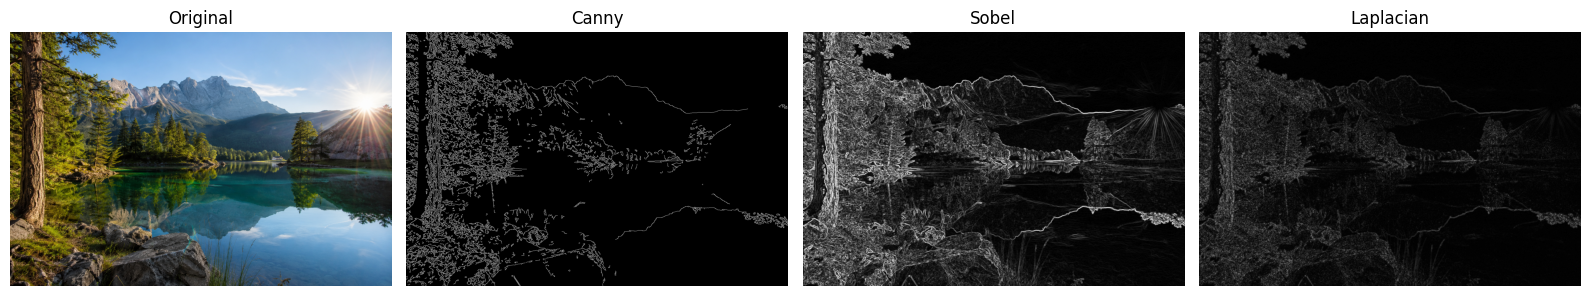

In [5]:
titles = [
    "Original",
    "Canny",
    "Sobel",
    "Laplacian"
]

results = [
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    canny_result,
    sobel_result,
    laplacian_result
]

plt.figure(figsize=(16, 5))

for index in range(4):
    plt.subplot(1, 4, index + 1)

    if index == 0:
        plt.imshow(results[index])
    else:
        plt.imshow(results[index], cmap="gray")

    plt.title(titles[index])
    plt.axis("off")

plt.tight_layout()
plt.show()

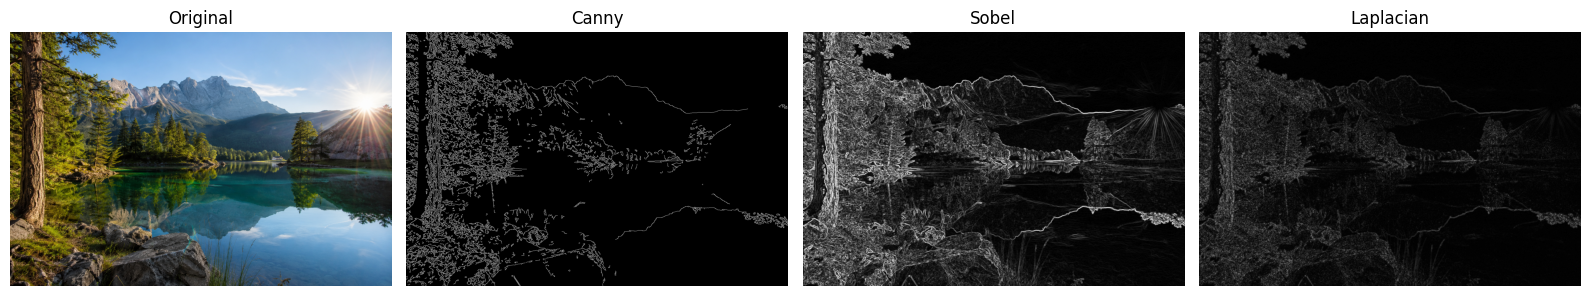

Da luu anh: C:\Users\LENOVO\Downloads\lab2.2 (1)\data\output\comparison\algorithm_comparison.png


In [6]:
output_folder = (
    project_folder
    / "data/output/comparison"
)

output_folder.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_folder
    / "algorithm_comparison.png"
)

figure, axes = plt.subplots(
    1,
    4,
    figsize=(16, 5)
)

for index in range(4):
    if index == 0:
        axes[index].imshow(results[index])
    else:
        axes[index].imshow(
            results[index],
            cmap="gray"
        )

    axes[index].set_title(titles[index])
    axes[index].axis("off")

figure.tight_layout()

figure.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Da luu anh:", output_path)

# So sánh các thuật toán phát hiện biên

Notebook này sử dụng cùng một ảnh đầu vào `sample.png` để so sánh
ba thuật toán phát hiện biên: Canny, Sobel và Laplacian.

Quy trình xử lý chung:

1. Chuyển ảnh BGR sang ảnh xám.
2. Làm mờ ảnh bằng Gaussian Blur.
3. Thực hiện phát hiện biên.
4. Hiển thị và so sánh kết quả.

Thông số sử dụng:

- Canny: low threshold = 100, high threshold = 200.
- Sobel: kernel size = 3.
- Laplacian: kernel size = 3.
- Gaussian Blur: kernel size = (5, 5), sigma = 1.0.

In [ ]:
## Nhận xét kết quả

- Canny tạo đường biên mảnh, rõ ràng và hạn chế nhiễu tốt.
- Sobel thể hiện rõ sự thay đổi cường độ theo chiều ngang và dọc,
  nhưng đường biên thường dày hơn.
- Laplacian phát hiện được nhiều chi tiết nhỏ nhưng nhạy với nhiễu.
- Nhìn chung, Canny cho kết quả cân bằng và dễ quan sát nhất trên
  ảnh thử nghiệm này.